## Playing around with attendance data

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

cities = pd.read_csv("../data/cities.csv")

# I'm going to assume "trip" == "event"
events = pd.read_excel("../data/MHC Trip Summary.xlsx")
# Remove nans for city and site type 
events = events.dropna(subset=["City", "Site Types"])

# Fill the remaining gaps with zeros
events.loc[:,nan2zero_cols] = events.loc[:,nan2zero_cols].fillna(0)


events = pd.merge(events, cities.loc[:,["city","pop"]], left_on="City", right_on="city")

# Split multi-valued items
events["Site Types"] = events["Site Types"].apply(lambda st : np.array(st.split(";")) )
events["Site Types Pretty"] = events["Site Types"].apply(lambda st : ", ".join(st) )

# Total foot traffic calculation
events["Foot traffic"] = events["Total patients screened"]


display(events)



,Date,City,Physical location,Site Types,Latitude,Longitude,Organizer,Services offered,Total Pharmacists,Total APPE Students,...,Patients referred to other sites.1,Patients needing f/u.1,Patients who were seen at f/u.1,Patients not seen at f/u.1,New diagnosis noted at f/u.1,Interventions made at appointment.1,city,pop,Site Types Pretty,Foot traffic
0,2024-08-02 00:00:00,Ottawa,Ottawa Schools,[Special Event],41.028836,-84.046572,HealthWise,BP + BG,3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Ottawa,4456,Special Event,28
1,2024-08-06 00:00:00,Lima,Mercy Thrift Store,[Thrift store],40.743039,-84.111477,HealthWise,MHC,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Lima,35579,Thrift store,1
2,2024-08-07 00:00:00,Lima,Lima Library,[Library],40.740543,-84.115236,HealthWise,MHC,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Lima,35579,Library,3
3,2024-08-13 00:00:00,Kenton,Kenton Seton,[Senior community],40.654257,-83.591779,HealthWise,NaN,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,Kenton,7947,Senior community,3
4,2024-08-14 00:00:00,Bluffton,Bluffton Library,[Library],40.892385,-83.892901,HealthWise,MHC,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Bluffton,3967,Library,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,2025-05-07 00:00:00,Lima,Christian Corner,[Food Bank],40.712793,-84.107995,HealthWise,MHC,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Lima,35579,Food Bank,10
109,2025-05-08 00:00:00,Bluffton,Bluffton Library,[Library],40.892385,-83.892901,HealthWise,NaN,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Bluffton,3967,Library,7
110,2025-05-09 00:00:00,Wapakoneta,Wapak UCC,[Church],40.569259,-84.195249,HealthWise,MHC,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Wapakoneta,9957,Church,6
111,5/13/2025-5/15/2025,Ada,Employee screenings,[Special Event],40.767245,-83.830893,HealthWise,Bone density + skin scope,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Ada,5334,Special Event,31


## Helper functions

In [78]:
def remove_special_events(events):

    no_special_events_mask = np.logical_not(events["Site Types"].apply(lambda t : (t == "Special Event").all()))
    return events.loc[no_special_events_mask,:]



def plot_site_scatter(events, filter_value=None, legend=True, group_attr="Physical location", x_var="pop"):

    events = remove_special_events(events)

    if filter_value != None: 
        site_type_mask = events["Site Types"].apply(lambda t : (t == filter_value).any())
        events = events.loc[site_type_mask,:]

    site_set = set(events[group_attr])

    fig, ax = plt.subplots()

    for site in site_set:
        x = events.loc[events[group_attr] == site, x_var]
        y = events.loc[events[group_attr] == site,"Foot traffic"]

        current_city = events.loc[events[group_attr] == site,"city"].values[0]

        label = f"{site}"
        ax.scatter(x, y, label=label)

    if legend:
        plt.legend(loc="center left", bbox_to_anchor=(1,0.5))

    if filter_value is not None:
        plt.title(f"Expected attendance at {filter_value} sites")
    else:
        plt.title(f"Expected attendance across all sites")

    ax.set_xlabel(x_var)
    ax.set_ylabel("Foot traffic")
    fig.set_size_inches(8, 5)

    return ax

## Examining attenance as a function of population and site type
_Reflections_: It doesn't seem that population is a big determinant of expected attendance 

<Axes: title={'center': 'Expected attendance at Library sites'}, xlabel='pop', ylabel='Foot traffic'>

<Axes: title={'center': 'Expected attendance at Thrift store sites'}, xlabel='pop', ylabel='Foot traffic'>

<Axes: title={'center': 'Expected attendance at Charitable Meal sites'}, xlabel='pop', ylabel='Foot traffic'>

<Axes: title={'center': 'Expected attendance at Senior community sites'}, xlabel='pop', ylabel='Foot traffic'>

<Axes: title={'center': 'Expected attendance at Gym sites'}, xlabel='pop', ylabel='Foot traffic'>

<Axes: title={'center': 'Expected attendance at Church sites'}, xlabel='pop', ylabel='Foot traffic'>

<Axes: title={'center': 'Expected attendance at Food pantry sites'}, xlabel='pop', ylabel='Foot traffic'>

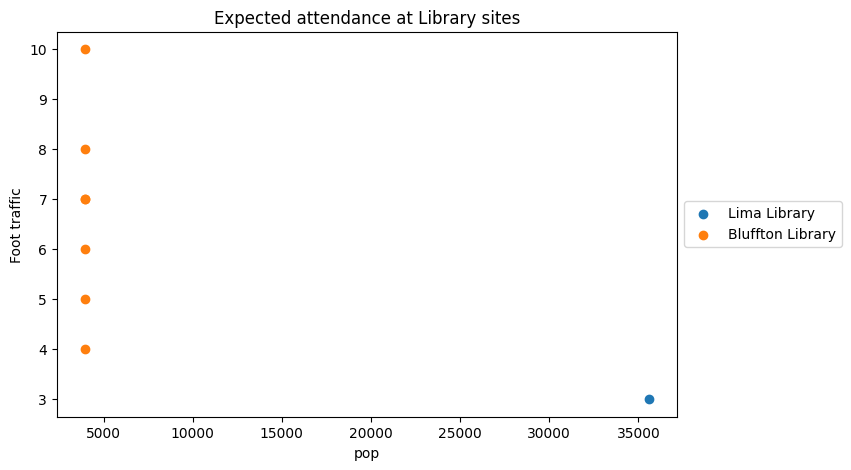

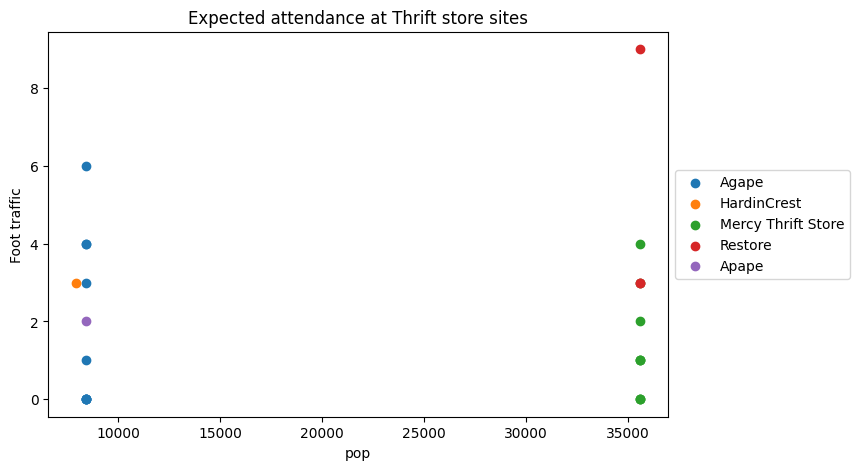

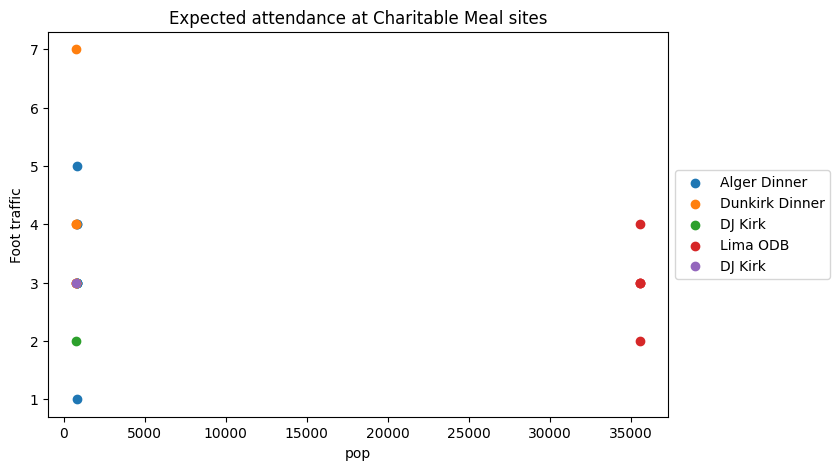

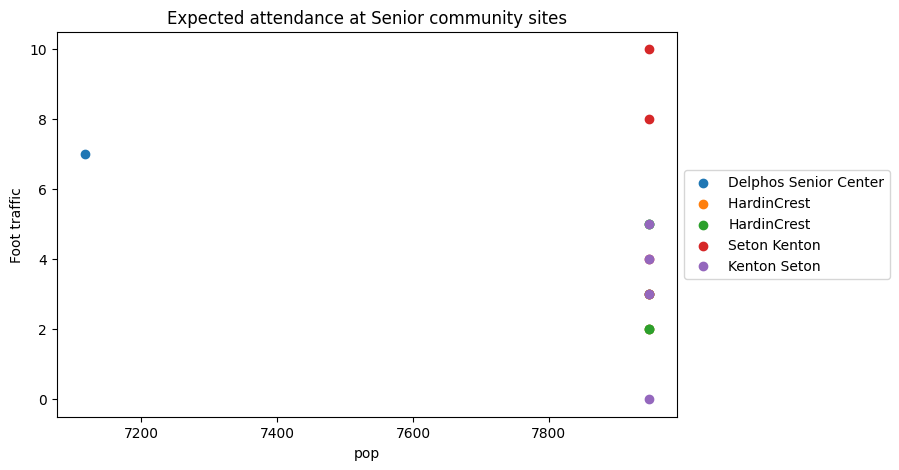

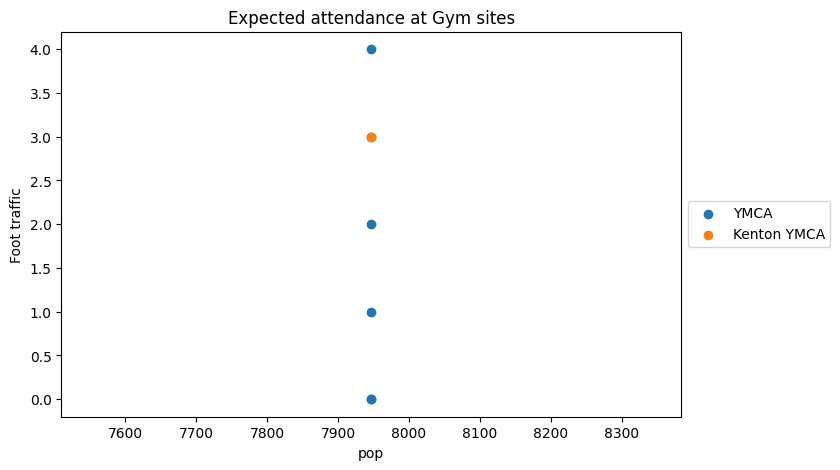

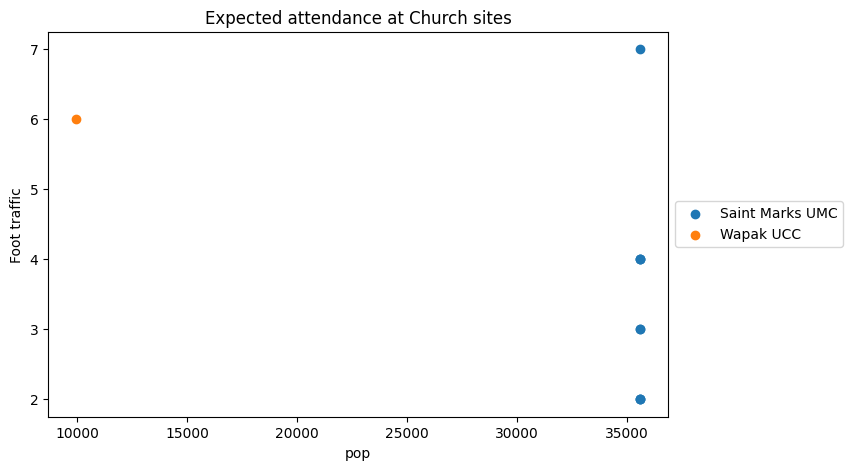

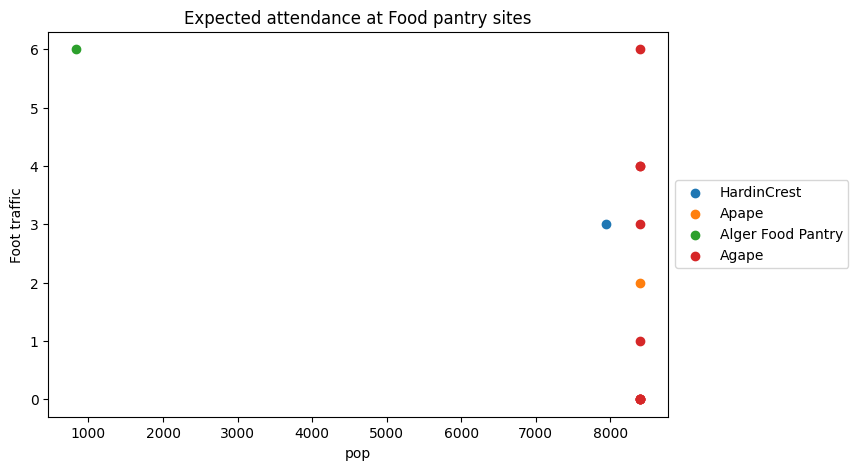

In [84]:
ax = plot_site_scatter(events, filter_value="Library")
display(ax)

ax = plot_site_scatter(events, filter_value="Thrift store")
display(ax)

ax = plot_site_scatter(events, filter_value='Charitable Meal')
display(ax)

ax = plot_site_scatter(events, filter_value="Senior community")
display(ax)

ax = plot_site_scatter(events, filter_value="Gym")
display(ax)

ax = plot_site_scatter(events, filter_value="Church")
display(ax)

ax = plot_site_scatter(events, "Food pantry")
display(ax)

## Examining attendance as a function of population
_Reflections:_ It looks like population really isn't a big determinant of expected attendance 

<Axes: title={'center': 'Expected attendance across all sites'}, xlabel='Population of city', ylabel='Foot traffic'>

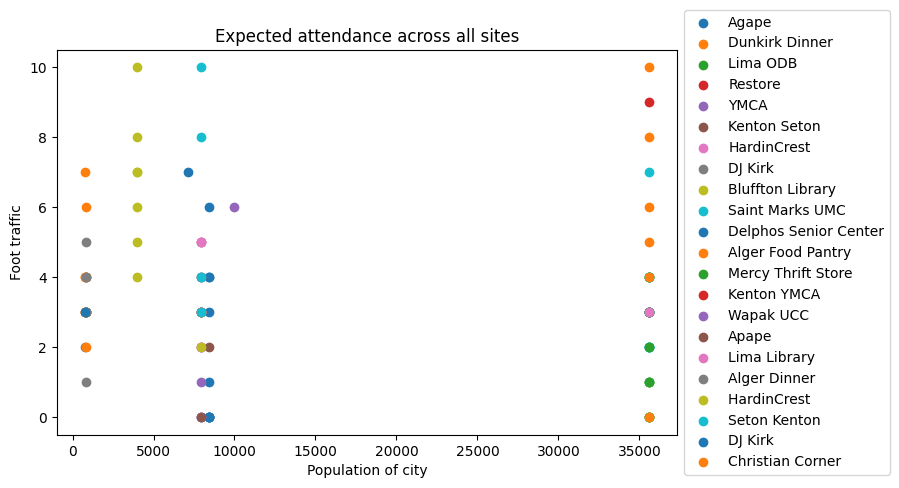

In [83]:
ax = plot_site_scatter(events, legend=True, group_attr="Physical location")
ax.set_xlabel("Population of city")
display(ax);

## Examining event type versus attendance

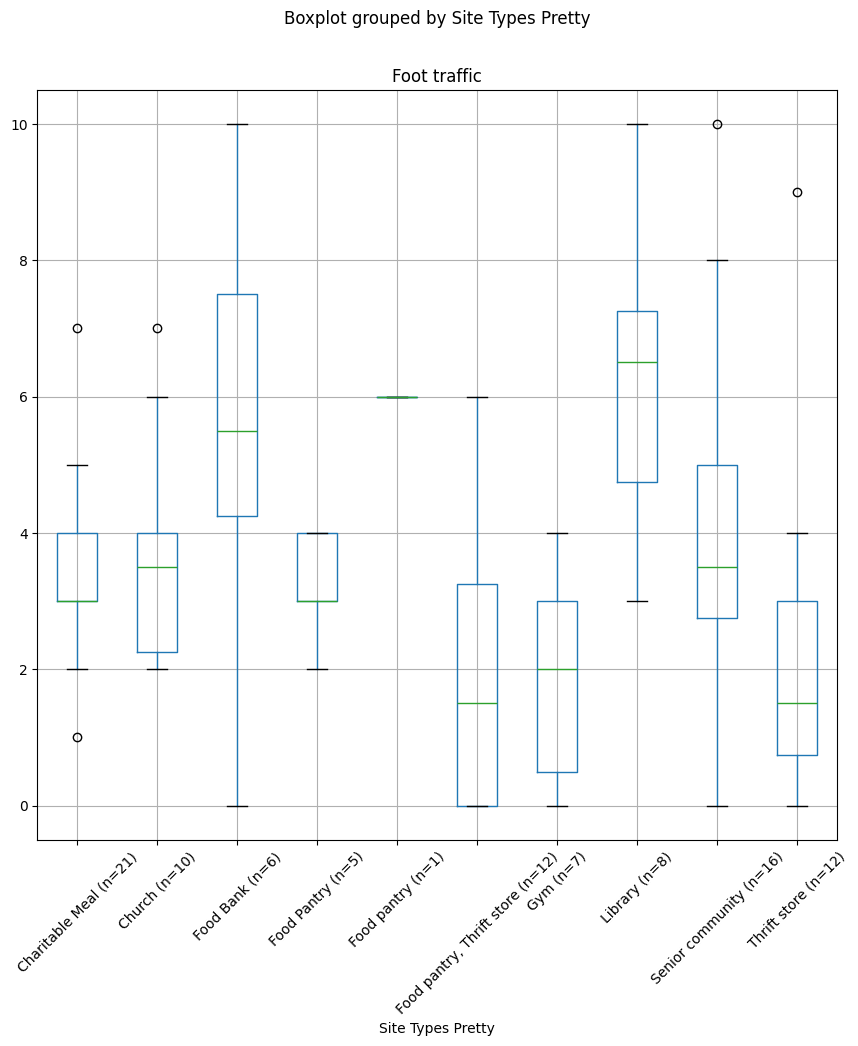

In [74]:
events_no_special = remove_special_events(events)

counts = events_no_special['Site Types Pretty'].value_counts()
new_labels = [f"{label} (n={counts[label]})" for label in counts.index]
ax = events_no_special.boxplot(column="Foot traffic", by="Site Types Pretty", figsize=(10,10), rot=45)
new_labels.sort()
ax.set_xticklabels(new_labels);


## Examining city versus attendance

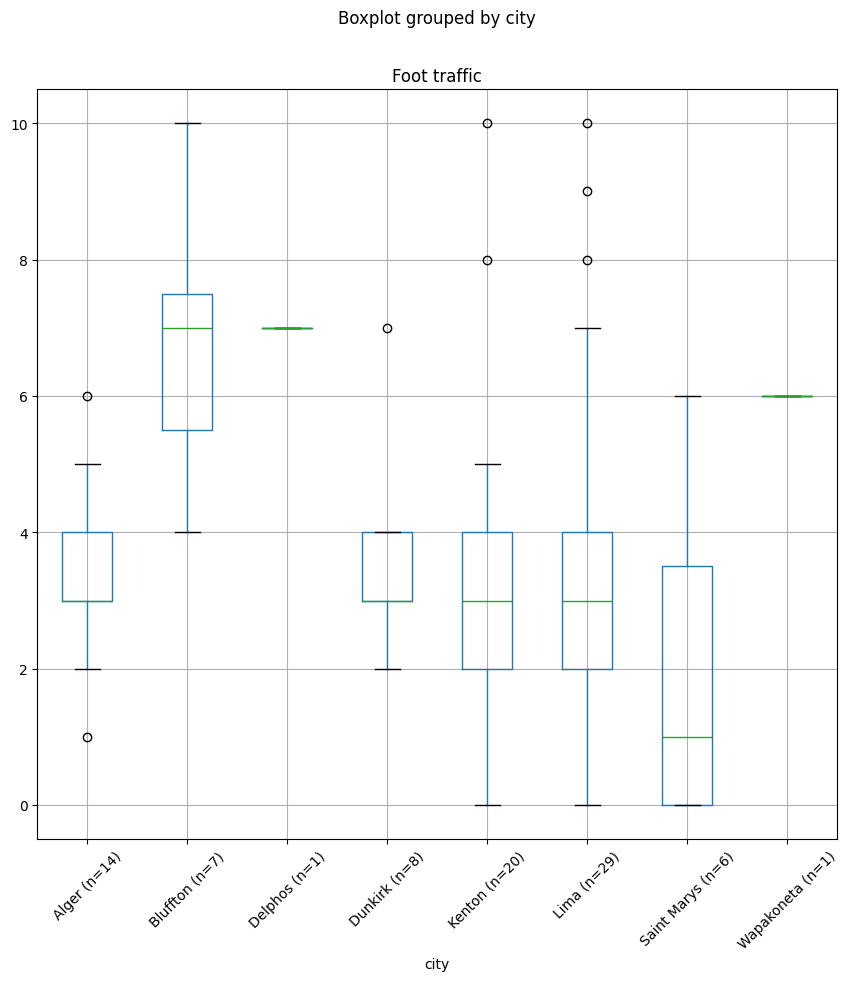

In [75]:
counts = events_no_special.loc[events_no_special["Foot traffic"] > 0, 'city'].value_counts()
new_labels = [f"{label} (n={counts[label]})" for label in counts.index]
new_labels.sort()
ax = events_no_special.boxplot(column="Foot traffic", by="city", figsize=(10,10),rot=45)
ax.set_xticklabels(new_labels);

## Corellation analysis
... yes I realize the city values and the types doesn't make much sense. But meh. 
_Reflection:_ But!! Population size and foot traffic are very uncorrelated 

C:\Users\i-kropp\AppData\Local\Temp\ipykernel_22572\1651751771.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  numbery_events = numbery_events.replace({"city" : city_dict,


,Foot traffic,Site Types Pretty,pop,city,Physical location
Foot traffic,1.000000,-0.111259,-0.076983,0.095052,0.194017
Site Types Pretty,-0.111259,1.000000,0.040909,-0.091914,-0.161951
pop,-0.076983,0.040909,1.000000,-0.582779,0.129516
city,0.095052,-0.091914,-0.582779,1.000000,0.160899
Physical location,0.194017,-0.161951,0.129516,0.160899,1.000000


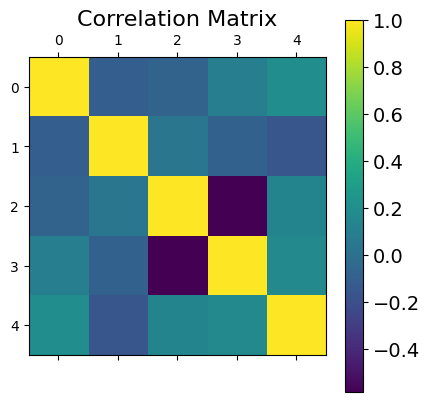

In [76]:
def dictionize_df(df, attr): 
    discrete_vals = set(df.loc[:,attr].values)
    dictionary = {value: number for (number, value) in enumerate(discrete_vals)}
    return dictionary


city_dict = dictionize_df(events, "city")
loca_dict = dictionize_df(events, "Physical location")
type_dict = dictionize_df(events, "Site Types Pretty")

attributes = ["Foot traffic", "Site Types Pretty", "pop", "city", "Physical location"]
numbery_events = events_no_special.loc[:,attributes]
numbery_events = numbery_events.replace({"city" : city_dict, 
                                         "Physical location": loca_dict,
                                         "Site Types Pretty" : type_dict})


corr_mat = numbery_events.corr()
display(corr_mat)

plt.matshow(corr_mat)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);
plt.show()

